# Tugas 3 Data Mining - Perbaikan Tahapan Pemodelan

Notebook ini berisi perbaikan tahapan pemodelan dari paper:
**A Comparative Study of Machine Learning Models for Heart Disease Prediction Using Grid Search and Random Search for Hyperparameter Tuning (Arshad et al., 2024)**.

Fokus perbaikan pada Tugas 3:
1. Data exploration poin 3 sampai 10.
2. Data preprocessing berbasis hasil exploration (dengan alasan metode).
3. Pemodelan menggunakan **Stratified Cross-Validation**.
4. Perbandingan hasil cross-validation vs hasil pada data test.


Kelompok 5


*   Gafna Al Faatiha Prabowo 	(23/516550/PA/22099)
*   Syafran Abdillah Erdin	 (23/521752/PA/22444)
*   Iqbal Pandu Santoso		 (23/517100/PA/22150)
*   Dzikran Azka Sajidan 	 (23/516665/PA/22110)



## Ringkasan Perbaikan dari Tugas 2

Pada Tugas 2, model sudah berjalan tetapi masih ada beberapa risiko metodologis:
- belum ada eksplorasi data yang lengkap (poin 3-10),
- potensi data leakage dari baris duplikat,
- nilai tidak valid (contoh `cholesterol = 0`) belum ditangani sebagai missing,
- validasi model belum menggunakan stratified cross-validation secara eksplisit,
- perbandingan performa CV dan performa test belum disajikan berdampingan.

Di notebook ini, semua poin tersebut diperbaiki agar alur lebih kuat secara metodologis.


In [ ]:

# !pip install pandas numpy matplotlib seaborn scikit-learn kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    cohen_kappa_score,
    matthews_corrcoef,
    make_scorer,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## Load Data

In [ ]:
file_path = "heart_statlog_cleveland_hungary_final.csv"

df_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/heart-statlog-cleveland-hungary-final",
    file_path,
)
print(f"Ukuran data awal: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom")


/tmp/ipykernel_6970/1024288602.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_raw = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-statlog-cleveland-hungary-final' dataset.
Ukuran data awal: 1190 baris, 12 kolom


## Data Exploration (Poin 3 s/d 10)

### 3) Initial Data Examination

In [ ]:
display(df_raw.head())
display(df_raw.tail())
display(df_raw.sample(5, random_state=42))

print("Shape:", df_raw.shape)
print()
print("Info dataset:")
df_raw.info()


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0000,1,0
1,49,0,3,160,180,0,0,156,0,1.0000,2,1
2,37,1,2,130,283,0,1,98,0,0.0000,1,0
3,48,0,4,138,214,0,0,108,1,1.5000,2,1
4,54,1,3,150,195,0,0,122,0,0.0000,1,0


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1185,45,1,1,110,264,0,0,132,0,1.2000,2,1
1186,68,1,4,144,193,1,0,141,0,3.4000,2,1
1187,57,1,4,130,131,0,0,115,1,1.2000,2,1
1188,57,0,2,130,236,0,2,174,0,0.0000,2,1
1189,38,1,3,138,175,0,0,173,0,0.0000,1,0


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
390,61,1,4,160,0,1,1,145,0,1.0000,2,1
247,54,1,3,120,237,0,0,150,1,1.5000,2,1
260,55,0,2,122,320,0,0,155,0,0.0000,1,0
155,56,1,4,155,342,1,0,150,1,3.0000,2,1
984,60,0,4,150,258,0,2,157,0,2.6000,2,1


Shape: (1190, 12)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


**Interpretasi poin 3**

- Dataset berisi **1190 baris** dan **12 kolom** (11 fitur + 1 target).
- Semua kolom sudah numerik (`int64` atau `float64`).
- Target bersifat biner (`0` dan `1`), sehingga masalah ini adalah klasifikasi biner.


### 4) Check for Duplicate Rows

In [ ]:
duplicate_count = df_raw.duplicated().sum()
duplicate_ratio = duplicate_count / len(df_raw)

print(f"Jumlah duplikat: {duplicate_count} baris")
print(f"Proporsi duplikat: {duplicate_ratio:.2%}")

if duplicate_count > 0:
    print()
    print("Contoh baris duplikat:")
    display(df_raw[df_raw.duplicated()].head())


Jumlah duplikat: 272 baris
Proporsi duplikat: 22.86%

Contoh baris duplikat:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
163,49,0,2,110,208,0,0,160,0,0.0000,1,0
604,58,1,3,150,219,0,1,118,1,0.0000,2,1
887,63,1,1,145,233,1,2,150,0,2.3000,3,0
888,67,1,4,160,286,0,2,108,1,1.5000,2,1
889,67,1,4,120,229,0,2,129,1,2.6000,2,1


**Interpretasi poin 4**

- Ditemukan **272 baris duplikat** (sekitar **22.86%** data).
- Duplikat cukup besar dan berpotensi membuat evaluasi terlalu optimis jika data serupa muncul di train dan test.
- Karena itu, pada tahap preprocessing baris duplikat akan dihapus.


### 5) Summary Statistics

In [ ]:
display(df_raw.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,"1,190.0000",53.7202,9.3582,28.0000,47.0000,54.0000,60.0000,77.0000
sex,"1,190.0000",0.7639,0.4249,0.0000,1.0000,1.0000,1.0000,1.0000
chest pain type,"1,190.0000",3.2328,0.9355,1.0000,3.0000,4.0000,4.0000,4.0000
resting bp s,"1,190.0000",132.1538,18.3688,0.0000,120.0000,130.0000,140.0000,200.0000
cholesterol,"1,190.0000",210.3639,101.4205,0.0000,188.0000,229.0000,269.7500,603.0000
fasting blood sugar,"1,190.0000",0.2134,0.4099,0.0000,0.0000,0.0000,0.0000,1.0000
resting ecg,"1,190.0000",0.6983,0.8704,0.0000,0.0000,0.0000,2.0000,2.0000
max heart rate,"1,190.0000",139.7328,25.5176,60.0000,121.0000,140.5000,160.0000,202.0000
exercise angina,"1,190.0000",0.3874,0.4874,0.0000,0.0000,0.0000,1.0000,1.0000
oldpeak,"1,190.0000",0.9228,1.0863,-2.6000,0.0000,0.6000,1.6000,6.2000


**Interpretasi poin 5**

- Rata-rata umur pasien sekitar **53.7 tahun**.
- Variabel `cholesterol` memiliki rentang sangat lebar (0 sampai 603), mengindikasikan potensi nilai tidak valid/outlier.
- `oldpeak` juga memiliki variasi cukup tinggi dan cenderung right-skew.
- Distribusi target relatif seimbang (tidak ekstrem), tetapi tetap perlu stratifikasi saat split dan cross-validation.


### 6) Identify Missing Values

In [ ]:
# Missing values eksplisit (NaN)
missing_explicit = df_raw.isna().sum().to_frame("jumlah_missing_eksplisit")
display(missing_explicit.T)

# Cek nilai tidak valid yang lazim diperlakukan sebagai missing
invalid_zero_report = pd.DataFrame(
    {
        "kolom": ["cholesterol", "resting bp s", "ST slope"],
        "jumlah_nilai_0": [
            (df_raw["cholesterol"] == 0).sum(),
            (df_raw["resting bp s"] == 0).sum(),
            (df_raw["ST slope"] == 0).sum(),
        ],
    }
)
invalid_zero_report["persentase"] = invalid_zero_report["jumlah_nilai_0"] / len(df_raw)
display(invalid_zero_report)

# Buat versi data untuk EDA lanjut: 0 tidak valid dikonversi menjadi NaN
# (nilai 0 untuk kolom tersebut tidak realistis secara medis)
df_eda = df_raw.copy()
df_eda["cholesterol"] = df_eda["cholesterol"].replace(0, np.nan)
df_eda["resting bp s"] = df_eda["resting bp s"].replace(0, np.nan)
df_eda["ST slope"] = df_eda["ST slope"].replace(0, np.nan)

missing_after_recode = df_eda.isna().sum()
print("Missing setelah recoding nilai tidak valid -> NaN:")
print(missing_after_recode[missing_after_recode > 0])


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
jumlah_missing_eksplisit,0,0,0,0,0,0,0,0,0,0,0,0


,kolom,jumlah_nilai_0,persentase
0,cholesterol,172,0.1445
1,resting bp s,1,0.0008
2,ST slope,1,0.0008


Missing setelah recoding nilai tidak valid -> NaN:
resting bp s      1
cholesterol     172
ST slope          1
dtype: int64


**Interpretasi poin 6 (penting)**

- Secara eksplisit, data memang tidak punya NaN.
- Tetapi ditemukan pola nilai yang tidak valid:
  - `cholesterol = 0` sebanyak **172 baris** (~14.45%),
  - `resting bp s = 0` sebanyak **1 baris**,
  - `ST slope = 0` sebanyak **1 baris**.
- Nilai ini tidak realistis secara domain medis, sehingga diperlakukan sebagai missing lalu diimputasi pada tahap preprocessing.


### 7) Check for Outliers

,kolom,Q1,Q3,IQR,lower_bound,upper_bound,jumlah_outlier,persentase_outlier
2,cholesterol,207.2500,275.0000,67.7500,105.6250,376.6250,23,0.0308
1,resting bp s,120.0000,140.0000,20.0000,90.0000,170.0000,27,0.0294
4,oldpeak,0.0000,1.5000,1.5000,-2.2500,3.7500,16,0.0174
3,max heart rate,120.0000,156.0000,36.0000,66.0000,210.0000,2,0.0022
0,age,47.0000,60.0000,13.0000,27.5000,79.5000,0,0.0000


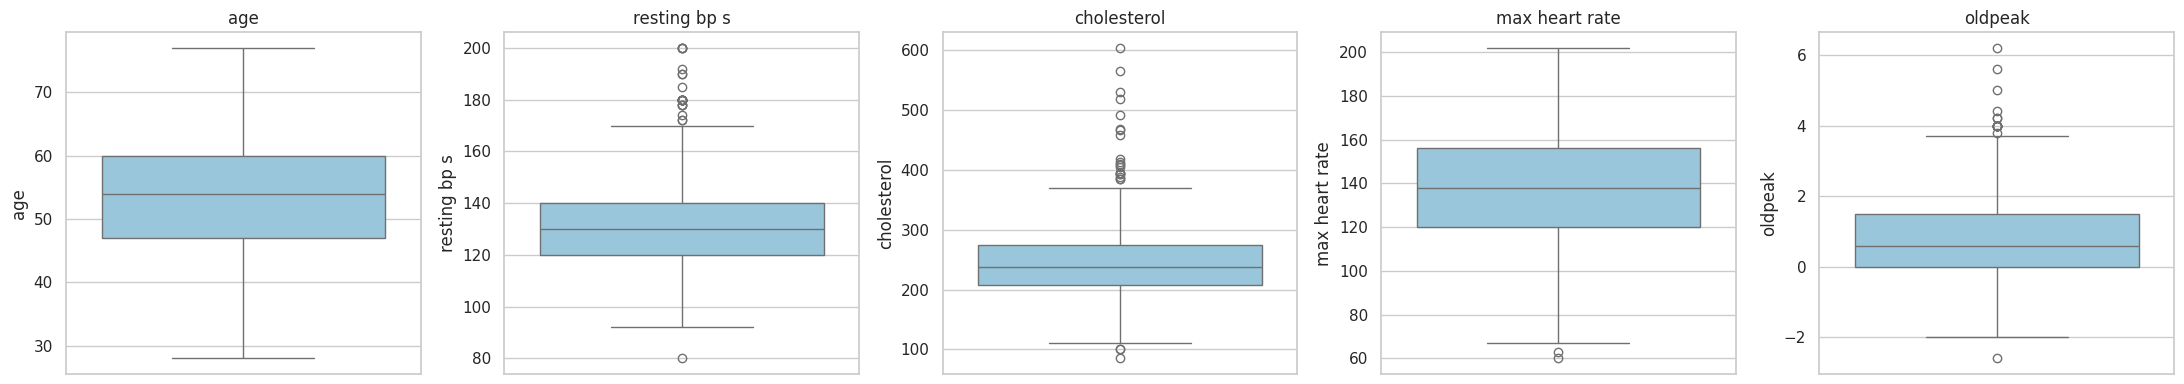

In [ ]:
numeric_cols = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]

df_eda_nodup = df_eda.drop_duplicates().reset_index(drop=True)

outlier_rows = []
for col in numeric_cols:
    s = df_eda_nodup[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outlier = ((s < lower) | (s > upper)).sum()

    outlier_rows.append(
        {
            "kolom": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "jumlah_outlier": int(n_outlier),
            "persentase_outlier": n_outlier / len(s),
        }
    )

outlier_table = pd.DataFrame(outlier_rows).sort_values("persentase_outlier", ascending=False)
display(outlier_table)

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(22, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_eda_nodup, y=col, ax=axes[i], color="#8ecae6")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


**Interpretasi poin 7 (penting)**

- Outlier paling terlihat pada `resting bp s` (~2.94%), `cholesterol` (~3.08%), dan `oldpeak` (~1.74%).
- Karena ini data medis, nilai ekstrem tidak selalu salah (bisa mencerminkan kondisi klinis berat).
- Oleh karena itu outlier **tidak langsung dihapus**, tetapi ditangani dengan pendekatan robust pada preprocessing (imputasi median + `RobustScaler`).


### 8) Explore Data Distributions

Skewness tiap fitur numerik:
cholesterol       1.2385
oldpeak           1.0229
resting bp s      0.6072
max heart rate   -0.1444
age              -0.1959
dtype: float64


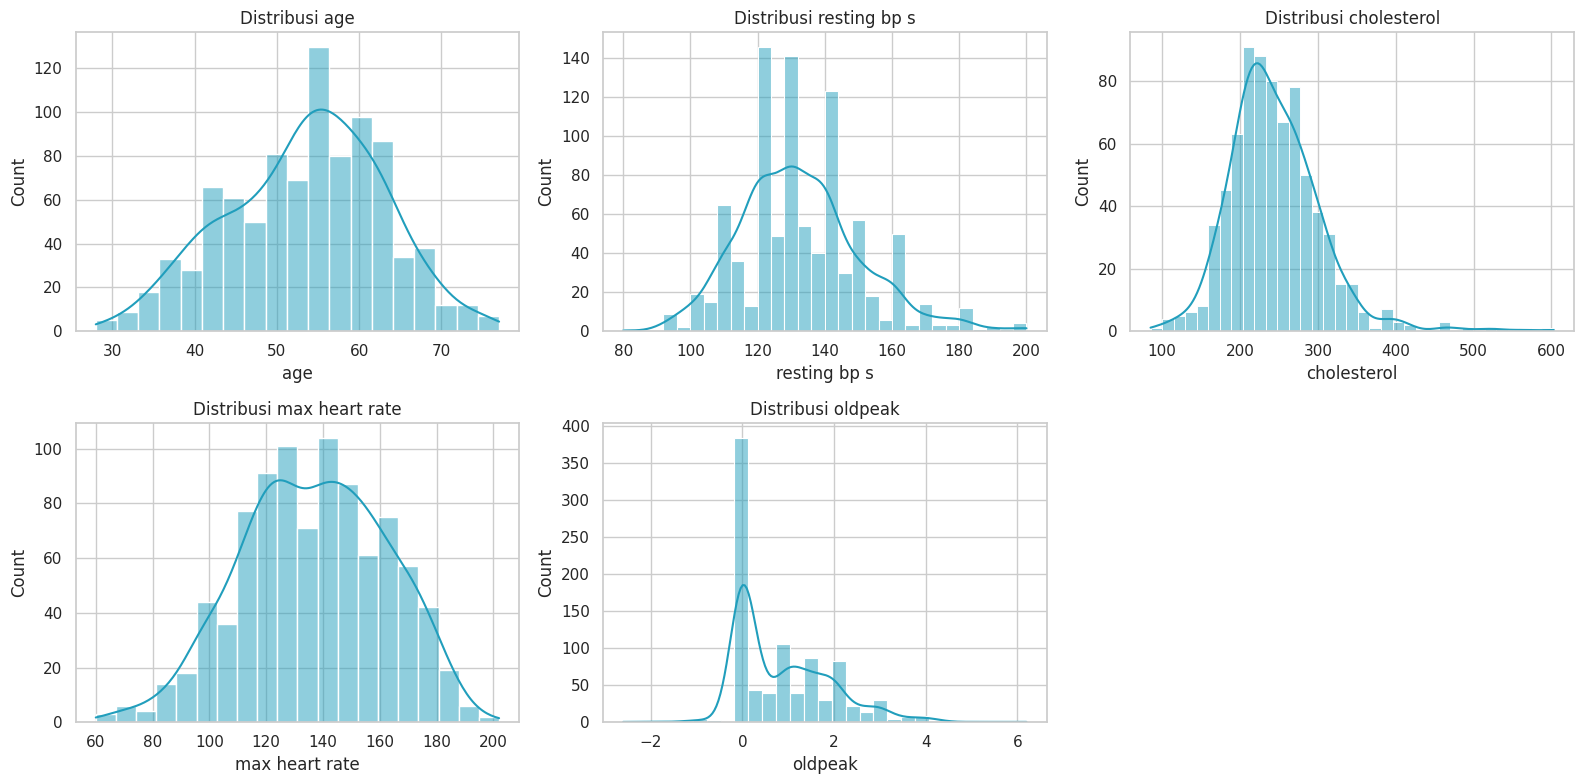

In [ ]:
skewness = df_eda_nodup[numeric_cols].skew().sort_values(ascending=False)
print("Skewness tiap fitur numerik:")
print(skewness)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_eda_nodup, x=col, kde=True, ax=axes[i], color="#219ebc")
    axes[i].set_title(f"Distribusi {col}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Interpretasi poin 8 (penting)**

- `cholesterol` dan `oldpeak` terlihat **right-skewed** (ekor kanan panjang).
- `age` dan `max heart rate` relatif lebih mendekati distribusi simetris.
- Implikasi ke preprocessing: scaling robust dipilih agar model yang sensitif skala (KNN, SVM, Logistic Regression) tidak terlalu terpengaruh oleh ekor distribusi dan outlier.


### 9) Categorical Data Exploration

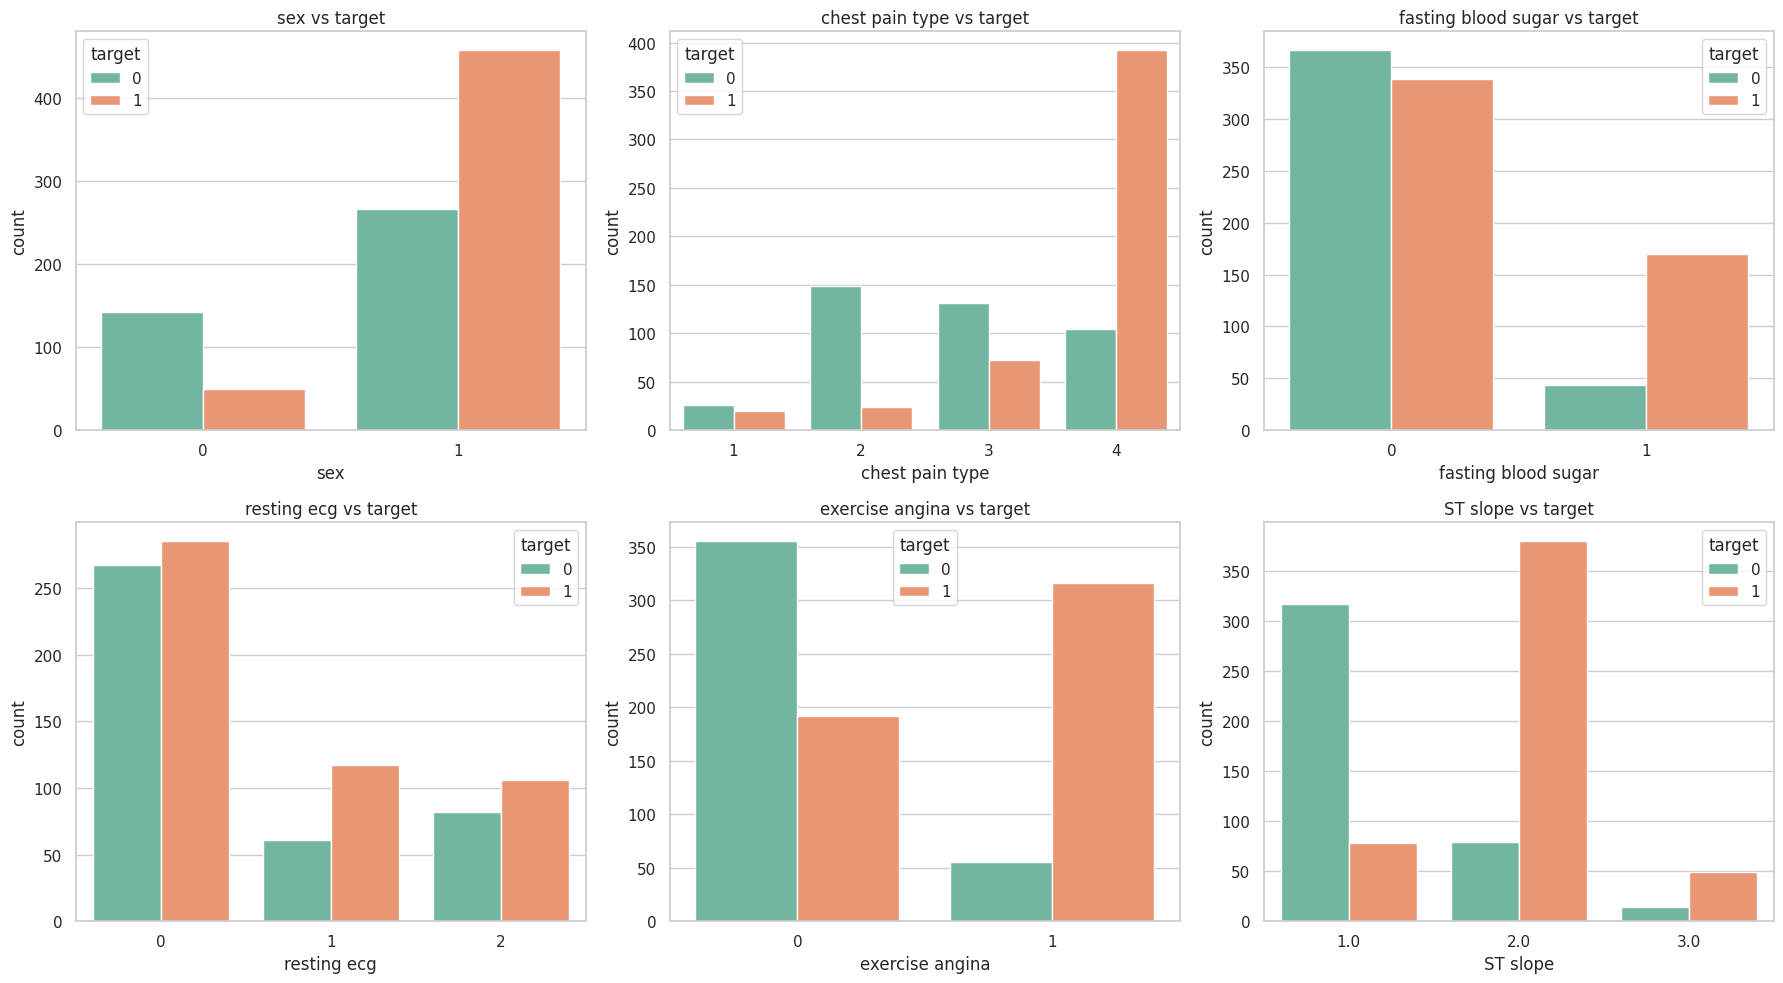

,fitur,kategori,proporsi_target_0,proporsi_target_1
12,exercise angina,1.0000,0.1482,0.8518
14,ST slope,2.0000,0.1721,0.8279
7,fasting blood sugar,1.0000,0.2056,0.7944
5,chest pain type,4.0000,0.2097,0.7903
15,ST slope,3.0000,0.2222,0.7778
9,resting ecg,1.0000,0.3427,0.6573
1,sex,1.0000,0.3683,0.6317
10,resting ecg,2.0000,0.4362,0.5638
8,resting ecg,0.0000,0.4837,0.5163
6,fasting blood sugar,0.0000,0.5199,0.4801


In [ ]:
categorical_cols = ["sex", "chest pain type", "fasting blood sugar", "resting ecg", "exercise angina", "ST slope"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_eda_nodup, x=col, hue="target", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs target")
    axes[i].legend(title="target", loc="best")
plt.tight_layout()
plt.show()

rows = []
for col in categorical_cols:
    tab = pd.crosstab(df_eda_nodup[col], df_eda_nodup["target"], normalize="index")
    for category, values in tab.iterrows():
        rows.append(
            {
                "fitur": col,
                "kategori": category,
                "proporsi_target_0": values.get(0, 0.0),
                "proporsi_target_1": values.get(1, 0.0),
            }
        )

cat_target_profile = pd.DataFrame(rows).sort_values("proporsi_target_1", ascending=False)
display(cat_target_profile.head(15))


**Interpretasi poin 9 (penting)**

- Fitur kategorikal yang paling membedakan target terlihat pada:
  - `exercise angina` (kategori 1 dominan target 1),
  - `ST slope` (kategori 2 dan 3 dominan target 1),
  - `chest pain type` (kategori 4 dominan target 1, kategori 2 dominan target 0).
- Karena meskipun nilainya berupa angka, maknanya adalah kategori, maka untuk pemodelan digunakan **One-Hot Encoding**.


### 10) Correlation Analysis

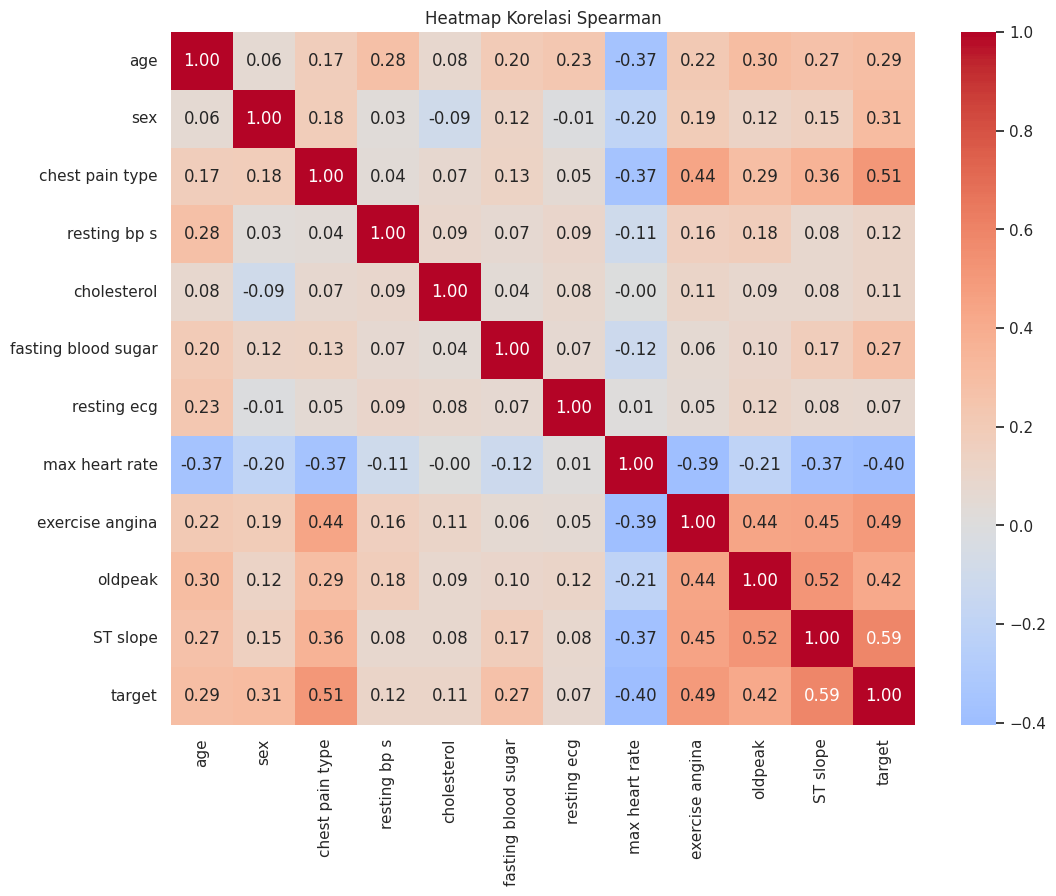

Korelasi (Spearman) terhadap target:


,korelasi_spearman_ke_target
ST slope,0.5917
chest pain type,0.5116
exercise angina,0.4943
oldpeak,0.4190
max heart rate,-0.4048
sex,0.3054
age,0.2896
fasting blood sugar,0.2673
resting bp s,0.1158
cholesterol,0.1149


In [ ]:
corr_spearman = df_eda_nodup.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_spearman, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Heatmap Korelasi Spearman")
plt.show()

corr_target = corr_spearman["target"].drop("target").sort_values(key=lambda x: x.abs(), ascending=False)
print("Korelasi (Spearman) terhadap target:")
display(corr_target.to_frame("korelasi_spearman_ke_target"))


**Interpretasi poin 10 (penting)**

- Fitur dengan korelasi relatif kuat ke target: `ST slope`, `chest pain type`, `exercise angina`, `oldpeak`, dan `max heart rate` (negatif).
- Tidak ada korelasi antarf fitur yang sangat ekstrem (mendekati +/-1), sehingga tidak ada fitur yang harus dibuang karena multikolinearitas berat.
- Korelasi ini sejalan dengan temuan visual pada poin 9.


## Data Preprocessing Berdasarkan Hasil Exploration

Keputusan preprocessing yang dipakai:
1. **Hapus duplikat** untuk mengurangi bias evaluasi.
2. **Recoding nilai tidak valid menjadi missing** (`cholesterol=0`, `resting bp s=0`, `ST slope=0`).
3. **Split train-test dengan stratify** agar proporsi kelas tetap terjaga.
4. **Imputasi missing**:
   - numerik -> median (lebih robust terhadap outlier),
   - kategorikal -> most frequent.
5. **Encoding kategorikal** -> One-Hot Encoding.
6. **Feature scaling numerik** -> RobustScaler (lebih tahan outlier dibanding StandardScaler).


In [ ]:
df_model = df_raw.copy()

# Recoding nilai tidak valid menjadi NaN
for col in ["cholesterol", "resting bp s"]:
    df_model[col] = df_model[col].replace(0, np.nan)
df_model["ST slope"] = df_model["ST slope"].replace(0, np.nan)

# Hapus duplikat
before_drop = len(df_model)
df_model = df_model.drop_duplicates().reset_index(drop=True)
after_drop = len(df_model)

X = df_model.drop(columns=["target"])
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

num_features = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]
cat_features = ["sex", "chest pain type", "fasting blood sugar", "resting ecg", "exercise angina", "ST slope"]

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, num_features),
        ("cat", categorical_preprocessor, cat_features),
    ]
)

print(f"Jumlah data sebelum drop duplikat: {before_drop}")
print(f"Jumlah data sesudah drop duplikat: {after_drop}")
print(f"Data train: {X_train.shape}, Data test: {X_test.shape}")
print()
print("Proporsi kelas train:")
print(y_train.value_counts(normalize=True))
print()
print("Proporsi kelas test:")
print(y_test.value_counts(normalize=True))


Jumlah data sebelum drop duplikat: 1190
Jumlah data sesudah drop duplikat: 918
Data train: (734, 11), Data test: (184, 11)

Proporsi kelas train:
target
1   0.5531
0   0.4469
Name: proportion, dtype: float64

Proporsi kelas test:
target
1   0.5543
0   0.4457
Name: proportion, dtype: float64


## Pemodelan Menggunakan Stratified Cross-Validation

Model yang dibandingkan tetap mengikuti paper agar konsisten:
- Logistic Regression
- KNN
- SVM (RBF)
- Random Forest
- Gradient Boosting
- Stacking Classifier

Validasi menggunakan **StratifiedKFold (5-fold)** dan multi-metrik:
Accuracy, Precision, Recall, F1, ROC-AUC, Kappa, dan MCC.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=11, weights="distance"),
    "SVM (RBF)": SVC(kernel="rbf", C=10, probability=True, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Stacking": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)),
            ("gb", GradientBoostingClassifier(random_state=42)),
        ],
        final_estimator=LogisticRegression(max_iter=3000),
        cv=5,
        n_jobs=-1,
    ),
}

stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "kappa": make_scorer(cohen_kappa_score),
    "mcc": make_scorer(matthews_corrcoef),
}


In [ ]:
cv_rows = []

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=stratified_cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_rows.append(
        {
            "Model": model_name,
            "CV Accuracy Mean": scores["test_accuracy"].mean(),
            "CV Accuracy Std": scores["test_accuracy"].std(),
            "CV Precision Mean": scores["test_precision"].mean(),
            "CV Recall Mean": scores["test_recall"].mean(),
            "CV F1 Mean": scores["test_f1"].mean(),
            "CV ROC-AUC Mean": scores["test_roc_auc"].mean(),
            "CV Kappa Mean": scores["test_kappa"].mean(),
            "CV MCC Mean": scores["test_mcc"].mean(),
        }
    )

cv_results = pd.DataFrame(cv_rows).sort_values("CV ROC-AUC Mean", ascending=False).reset_index(drop=True)
display(cv_results.round(4))

print(f"Model terbaik berdasarkan CV ROC-AUC: {cv_results.iloc[0]['Model']}")


,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV Kappa Mean,CV MCC Mean
0,Stacking,0.8583,0.0239,0.8654,0.8843,0.8737,0.9296,0.7124,0.7149
1,Random Forest,0.8556,0.0342,0.8547,0.8966,0.8736,0.9275,0.7055,0.7098
2,Logistic Regression,0.8365,0.0253,0.8603,0.8448,0.8516,0.9221,0.6695,0.6714
3,Gradient Boosting,0.8597,0.0228,0.8759,0.8720,0.8732,0.9186,0.7161,0.7176
4,KNN,0.8610,0.0290,0.8603,0.8966,0.8775,0.9141,0.7172,0.7192
5,SVM (RBF),0.8283,0.0363,0.8504,0.8400,0.8445,0.9003,0.6530,0.6542


Model terbaik berdasarkan CV ROC-AUC: Stacking


**Komentar hasil cross-validation**

- Tabel di atas menunjukkan performa rata-rata 5-fold stratified CV.
- Untuk kasus medis, ROC-AUC dan F1 penting karena kita ingin keseimbangan antara deteksi kasus positif dan false alarm.
- Model dengan skor CV tinggi lalu stabil pada data test akan diprioritaskan.


## Evaluasi pada Data Test dan Perbandingan dengan Hasil CV

In [ ]:
test_rows = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipeline

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        decision = pipeline.decision_function(X_test)
        y_score = (decision - decision.min()) / (decision.max() - decision.min())

    test_rows.append(
        {
            "Model": model_name,
            "Test Accuracy": accuracy_score(y_test, y_pred),
            "Test Precision": precision_score(y_test, y_pred, zero_division=0),
            "Test Recall": recall_score(y_test, y_pred, zero_division=0),
            "Test F1": f1_score(y_test, y_pred, zero_division=0),
            "Test ROC-AUC": roc_auc_score(y_test, y_score),
            "Test Kappa": cohen_kappa_score(y_test, y_pred),
            "Test MCC": matthews_corrcoef(y_test, y_pred),
        }
    )

test_results = pd.DataFrame(test_rows).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)
display(test_results.round(4))


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test Kappa,Test MCC
0,KNN,0.9130,0.9216,0.9216,0.9216,0.9448,0.8240,0.8240
1,Stacking,0.8859,0.8932,0.9020,0.8976,0.9341,0.7687,0.7688
2,Logistic Regression,0.8750,0.8990,0.8725,0.8856,0.9321,0.7479,0.7483
3,Random Forest,0.8859,0.8857,0.9118,0.8986,0.9306,0.7682,0.7686
4,Gradient Boosting,0.8696,0.8900,0.8725,0.8812,0.9142,0.7366,0.7368
5,SVM (RBF),0.8424,0.8687,0.8431,0.8557,0.9137,0.6822,0.6825


In [ ]:
comparison = cv_results[[
    "Model",
    "CV Accuracy Mean",
    "CV Precision Mean",
    "CV Recall Mean",
    "CV F1 Mean",
    "CV ROC-AUC Mean",
    "CV Kappa Mean",
    "CV MCC Mean",
]].merge(test_results, on="Model", how="inner")

comparison["Gap Accuracy (Test-CV)"] = comparison["Test Accuracy"] - comparison["CV Accuracy Mean"]
comparison["Gap F1 (Test-CV)"] = comparison["Test F1"] - comparison["CV F1 Mean"]
comparison["Gap ROC-AUC (Test-CV)"] = comparison["Test ROC-AUC"] - comparison["CV ROC-AUC Mean"]

comparison = comparison.sort_values("CV ROC-AUC Mean", ascending=False).reset_index(drop=True)
display(comparison.round(4))


,Model,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV Kappa Mean,CV MCC Mean,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test Kappa,Test MCC,Gap Accuracy (Test-CV),Gap F1 (Test-CV),Gap ROC-AUC (Test-CV)
0,Stacking,0.8583,0.8654,0.8843,0.8737,0.9296,0.7124,0.7149,0.8859,0.8932,0.9020,0.8976,0.9341,0.7687,0.7688,0.0275,0.0239,0.0045
1,Random Forest,0.8556,0.8547,0.8966,0.8736,0.9275,0.7055,0.7098,0.8859,0.8857,0.9118,0.8986,0.9306,0.7682,0.7686,0.0303,0.0249,0.0031
2,Logistic Regression,0.8365,0.8603,0.8448,0.8516,0.9221,0.6695,0.6714,0.8750,0.8990,0.8725,0.8856,0.9321,0.7479,0.7483,0.0385,0.0340,0.0099
3,Gradient Boosting,0.8597,0.8759,0.8720,0.8732,0.9186,0.7161,0.7176,0.8696,0.8900,0.8725,0.8812,0.9142,0.7366,0.7368,0.0099,0.0080,-0.0045
4,KNN,0.8610,0.8603,0.8966,0.8775,0.9141,0.7172,0.7192,0.9130,0.9216,0.9216,0.9216,0.9448,0.8240,0.8240,0.0520,0.0441,0.0307
5,SVM (RBF),0.8283,0.8504,0.8400,0.8445,0.9003,0.6530,0.6542,0.8424,0.8687,0.8431,0.8557,0.9137,0.6822,0.6825,0.0140,0.0112,0.0134


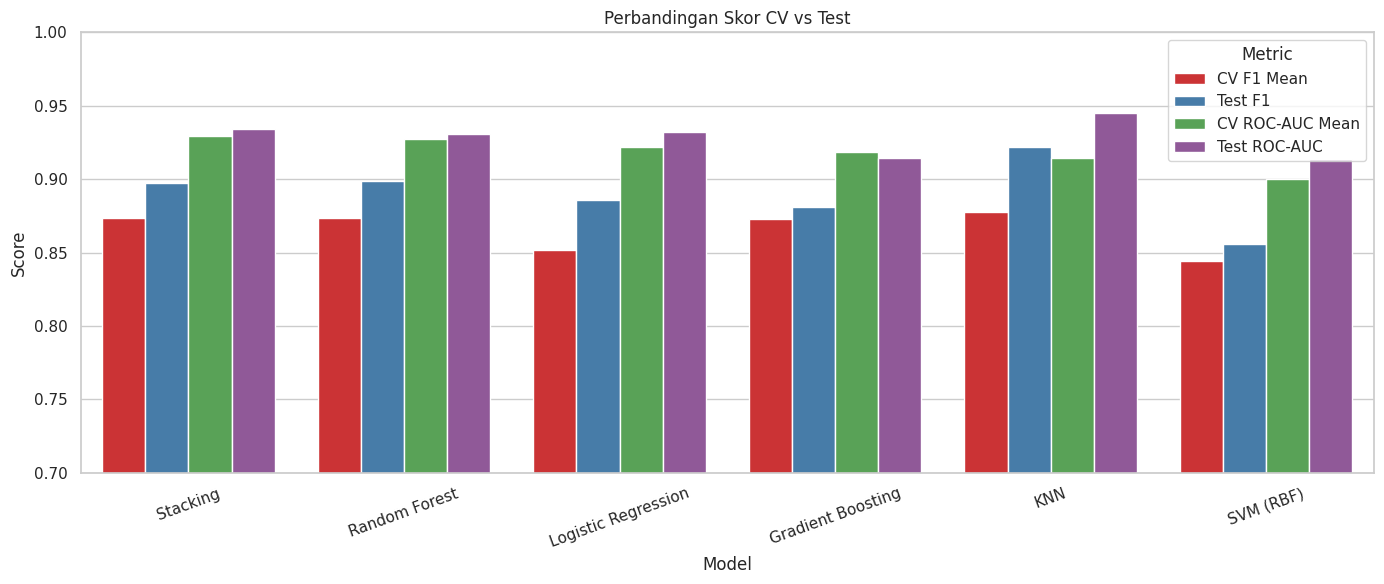

In [ ]:
# Visual perbandingan CV vs Test untuk metrik utama
plot_df = comparison[["Model", "CV F1 Mean", "Test F1", "CV ROC-AUC Mean", "Test ROC-AUC"]].copy()
plot_df = plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="Set1")
plt.ylim(0.7, 1.0)
plt.title("Perbandingan Skor CV vs Test")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Komentar perbandingan CV vs test**

- Jika skor test jauh lebih tinggi dari CV, kemungkinan evaluasi test sedang diuntungkan oleh pembagian data tertentu.
- Jika skor test jauh lebih rendah dari CV, kemungkinan model overfitting.
- Model yang paling konsisten adalah model dengan gap kecil antara CV dan test.


Model terbaik pada data test (berdasarkan ROC-AUC): KNN


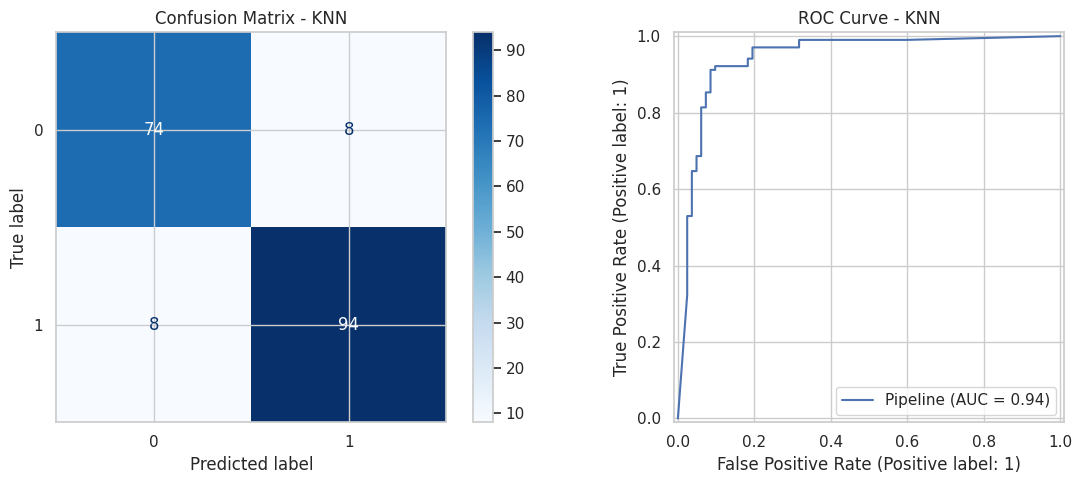

In [ ]:
# Tampilkan confusion matrix dan ROC curve untuk model terbaik di data test
best_test_model = test_results.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_test_model]

print(f"Model terbaik pada data test (berdasarkan ROC-AUC): {best_test_model}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion Matrix - {best_test_model}")

RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title(f"ROC Curve - {best_test_model}")

plt.tight_layout()
plt.show()


## Kesimpulan

Perbaikan tahapan pemodelan yang dilakukan:
1. Data exploration poin 3 sampai 10 sudah dilakukan lengkap dengan interpretasi.
2. Preprocessing disusun berdasarkan temuan EDA:
   - duplikat dihapus,
   - nilai tidak valid direcode ke missing,
   - imputasi + encoding + robust scaling dilakukan di dalam pipeline.
3. Pemodelan divalidasi dengan **Stratified Cross-Validation** sehingga evaluasi lebih adil untuk klasifikasi biner.
4. Kinerja model dibandingkan pada dua level:
   - performa rata-rata di stratified CV,
   - performa final di data test.

Dengan alur ini, hasil evaluasi lebih reliabel dibandingkan pendekatan sebelumnya yang belum eksplisit menangani duplikat, nilai tidak valid, dan stratifikasi validasi.
